# Washington's Cherry Blossoms Are Blooming Earlier — and That's a Problem for Pollinators

Every spring, the cherry trees around Washington D.C.'s Tidal Basin put on one of the most iconic floral displays in the country. Hundreds of thousands of people plan trips around the peak bloom. But quietly, year by year, those blossoms have been opening earlier — and the shift is happening fast enough that it's starting to matter for the insects that depend on them.

This analysis tracks **peak bloom dates for D.C.'s Yoshino cherry trees from 1921 to 2026**, drawing on over a century of records from the EPA and the National Park Service. The trend is striking: bloom is arriving roughly **9 days earlier today than it was in the 1920s**, with many of the most record-breaking early blooms concentrated in just the last decade.

**Why does this matter for pollinators?**  
Native bees and other early-spring pollinators time their emergence using temperature and daylight cues that have been stable for thousands of years. Cherry trees, responding to warming winters, are increasingly flowering *before* many of these pollinators are active. When flowers and pollinators fall out of sync — a phenomenon ecologists call *phenological decoupling* — both sides lose: the trees get less pollination, and the bees miss an early-season food source at exactly the moment they need it most.

**What the data show:**
- Peak bloom has advanced at about **−0.08 days per year** since 1921 — a trend that is highly statistically significant (p < 0.001)
- The shift is not smooth: interannual weather variation is large (bloom dates range across a full 34-day window), but the long-run direction is unmistakable
- The earliest bloom on record — **March 15, 1990** — would have seemed extraordinary in the early 20th century; today, several recent years have come close to matching it
- Local temperature anomalies (from a 24-station ensemble surrounding the Tidal Basin) track the bloom trend closely, reinforcing the climate signal

The cherry trees are, in a sense, a canary in the coal mine — a highly visible, well-documented indicator of the same seasonal reshuffling that is playing out more quietly across ecosystems everywhere. This Earth Day, they're worth paying attention to.

---
*Data: EPA Climate Change Indicators (1921–2016); NPS Bloom Watch (2004–2026); GHCN-M v4 temperature records (NASA GISS / NOAA). Analysis window: 1921–2026, N = 106 bloom years.*


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

os.makedirs("output", exist_ok=True)

# --- Cell 1: Load EPA cherry blossom data from CSV ---
# Source: EPA Climate Change Indicators in the United States
#   Original data: National Cherry Blossom Festival (2016); National Park Service (2015)
#   File: cherry-blossoms_fig-1.csv  (rows 1-6 are metadata; row 7 is header)
#   Units: Day of Year (DOY) — days from January 1

BLOOM_CSV = "cherry-blossoms_fig-1.csv"

df_bloom = pd.read_csv(BLOOM_CSV, skiprows=6)
df_bloom.columns = ["Year", "DOY", "Festival_Start", "Festival_Duration"]
df_bloom["Year"] = pd.to_numeric(df_bloom["Year"], errors="coerce")
df_bloom["DOY"]  = pd.to_numeric(df_bloom["DOY"],  errors="coerce")
df_bloom = df_bloom.dropna(subset=["Year", "DOY"]).astype({"Year": int, "DOY": float})

print(f"Loaded {len(df_bloom)} bloom records: {df_bloom.Year.min()}–{df_bloom.Year.max()}")
print(f"DOY range: {df_bloom.DOY.min():.0f} – {df_bloom.DOY.max():.0f}  (mean: {df_bloom.DOY.mean():.1f})")
print(df_bloom.head())

Loaded 96 bloom records: 1921–2016
DOY range: 74 – 108  (mean: 94.0)
   Year    DOY  Festival_Start  Festival_Duration
0  1921   79.0             NaN                NaN
1  1922   97.0             NaN                NaN
2  1923   99.0             NaN                NaN
3  1924  104.0             NaN                NaN
4  1925   86.0             NaN                NaN


In [2]:
# --- Cell 1b: Load NPS Bloom Watch data; merge with EPA series ---
# Bloom dates loaded from data/nps_bloom_watch.csv — a static file created from the
# NPS Bloom Watch page (https://www.nps.gov/subjects/cherryblossom/bloom-watch.htm,
# retrieved 2026-04-11). Edit that file to update or extend the record; do not hardcode
# dates in this notebook.
#
# Data merging decisions
# ─────────────────────
# 1. DOY computed from calendar date via datetime.strptime, accounting for leap years.
#    (Leap years in record: 2004, 2008, 2012, 2016, 2020, 2024.)
#
# 2. Overlap years 2004–2016 (13 years):
#    • 12 of 13 years agree exactly between EPA and NPS — as expected, since NPS
#      is one of the two original sources cited in the EPA file.
#    • 2008 is the sole conflict: EPA=89, NPS=86 (March 26 in a leap year).
#      Merged value = arithmetic mean = 87.5.
#    • For the 12 agreeing years the merged value equals both sources.
#
# 3. NPS-only years 2017–2026 (10 years) appended directly.
#    2026 is the current calendar year (today: 2026-04-11); bloom occurred March 26
#    and is already complete — included without reservation.
#
# 4. The merged df_bloom (N=106) replaces the EPA-only series for all downstream
#    analysis in Cells 2–4.

from datetime import datetime

NPS_CSV = "data/nps_bloom_watch.csv"

def date_to_doy(year, date_str):
    """Convert 'Month DD' string + year → day-of-year (leap-year aware)."""
    return datetime.strptime(f"{date_str} {year}", "%B %d %Y").timetuple().tm_yday

df_nps_raw = pd.read_csv(NPS_CSV, comment="#")
df_nps_raw["Year"] = df_nps_raw["Year"].astype(int)
df_nps = pd.DataFrame({
    "Year":    df_nps_raw["Year"],
    "DOY_nps": df_nps_raw.apply(lambda r: float(date_to_doy(r["Year"], r["Date"].strip())), axis=1),
})

# Outer merge so NPS-only years (2017–2026) are appended
df_merged = pd.merge(df_bloom[["Year", "DOY"]], df_nps, on="Year", how="outer")

# Classify source BEFORE overwriting DOY (while both originals are still present)
def _classify(r):
    has_epa = pd.notna(r["DOY"])
    has_nps = pd.notna(r["DOY_nps"])
    if has_epa and has_nps:
        return "Both (mean)" if r["DOY"] != r["DOY_nps"] else "Both (agree)"
    return "NPS only" if has_nps else "EPA only"

df_merged["Source"] = df_merged.apply(_classify, axis=1)

# Stash originals for the merge log before overwriting
_conflict_rows = df_merged[df_merged["Source"] == "Both (mean)"][["Year", "DOY", "DOY_nps"]].copy()

# Merge rule: mean when both present and differ; otherwise whichever is available
df_merged["DOY"] = df_merged.apply(
    lambda r: 0.5 * (r["DOY"] + r["DOY_nps"]) if pd.notna(r["DOY"]) and pd.notna(r["DOY_nps"])
              else r["DOY"] if pd.notna(r["DOY"])
              else r["DOY_nps"],
    axis=1
)

df_bloom = df_merged[["Year", "DOY", "Source"]].sort_values("Year").reset_index(drop=True)
df_bloom["Year"] = df_bloom["Year"].astype(int)

# --- Merge log ---
n_agree    = (df_merged["Source"] == "Both (agree)").sum()
n_conflict = len(_conflict_rows)
nps_only_yrs = sorted(df_merged[df_merged["Source"] == "NPS only"]["Year"].astype(int).tolist())

print(f"Loaded NPS data from {NPS_CSV}  ({len(df_nps_raw)} rows)")
print("Overlap years (2004–2016):")
print(f"  Exact agreements : {n_agree}")
if n_conflict:
    print(f"  Conflicts (→mean): {n_conflict}")
    for _, row in _conflict_rows.iterrows():
        print(f"    {int(row.Year)}: EPA={row.DOY:.0f}  NPS={row.DOY_nps:.0f}"
              f"  → mean={(row.DOY + row.DOY_nps) / 2:.1f}")
print(f"NPS-only years appended: {nps_only_yrs}")
print(f"Merged df_bloom: {df_bloom.Year.min()}–{df_bloom.Year.max()}  (N={len(df_bloom)})")
print(df_bloom.tail(12).to_string(index=False))


Loaded NPS data from data/nps_bloom_watch.csv  (23 rows)
Overlap years (2004–2016):
  Exact agreements : 12
  Conflicts (→mean): 1
    2008: EPA=89  NPS=86  → mean=87.5
NPS-only years appended: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Merged df_bloom: 1921–2026  (N=106)
 Year   DOY       Source
 2015 100.0 Both (agree)
 2016  85.0 Both (agree)
 2017  84.0     NPS only
 2018  95.0     NPS only
 2019  91.0     NPS only
 2020  80.0     NPS only
 2021  87.0     NPS only
 2022  80.0     NPS only
 2023  82.0     NPS only
 2024  77.0     NPS only
 2025  87.0     NPS only
 2026  85.0     NPS only


In [3]:
# --- Cell 2: Local temperature ensemble from NASA GISS / GHCN-M v4 stations ---
# Source: NOAA/NCEI GHCN Monthly (GHCNm) v4, Quality-Controlled (QCF) subset
#   URL: https://www.ncei.noaa.gov/pub/data/ghcn/v4/ghcnm.tavg.latest.qcf.tar.gz
#   GHCN-M v4 is the underlying station data source for NASA GISS GISTEMP.
#   Verify station IDs at: https://www.ncei.noaa.gov/pub/data/ghcn/v4/
#
# First-run behaviour: downloads ~44 MB tar.gz, extracts the two stations files
#   below, and writes them to disk. Subsequent runs load from disk.
#
# Local data files (in data/):
#   ghcnm_station_meta.csv  — station IDs, names, coordinates, distance from Tidal Basin
#   ghcnm_station_annual.csv — annual mean TAVG (°C) per station, one column per station
#   local_temp_ensemble.csv  — IDW ensemble anomaly series used in the analysis
#
# Approach: inverse-distance-weighted (IDW, 1/d²) ensemble of all GHCN-M v4 stations
#   within 25 km of the Tidal Basin cherry trees (38.889°N, 77.037°W).
#   Per-station anomalies computed relative to each station's own 1951–1980 mean.
#   A year is included only if ≥3 stations contribute (quality gate).

import io, tarfile, math, os
import numpy as np
from datetime import date as _date

GHCNM_URL   = "https://www.ncei.noaa.gov/pub/data/ghcn/v4/ghcnm.tavg.latest.qcf.tar.gz"
TIDAL_BASIN = (38.889, -77.037)
MAX_KM      = 25.0
BASELINE    = (1951, 1980)
MIN_STATIONS_PER_YEAR = 3

META_CSV     = "data/ghcnm_station_meta.csv"
ANNUAL_CSV   = "data/ghcnm_station_annual.csv"
ENSEMBLE_CSV = "data/local_temp_ensemble.csv"

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = math.radians(lat2 - lat1); dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1))*math.cos(math.radians(lat2))*math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

def fetch_ghcnm(url):
    import requests, warnings
    warnings.filterwarnings("ignore", message="Unverified HTTPS")
    r = requests.get(url, timeout=300, verify=False, stream=True)
    raw = b"".join(r.iter_content(chunk_size=1024*1024))
    with tarfile.open(fileobj=io.BytesIO(raw), mode="r:gz") as tf:
        names = tf.getnames()
        inv_name = next(m for m in names if m.endswith(".inv"))
        dat_name = next(m for m in names if m.endswith(".dat"))
        inv = tf.extractfile(inv_name).read().decode()
        dat = tf.extractfile(dat_name).read().decode()
    # extract version date from filename, e.g. ghcnm.tavg.v4.0.1.20260411.qcf.dat
    version = dat_name.split("/")[-1]
    return inv, dat, version

def find_nearby_stations(inv_text, center_lat, center_lon, max_km):
    stns = []
    for line in inv_text.strip().split("\n"):
        parts = line.split()
        if len(parts) < 3:
            continue
        try:
            sid  = parts[0]; lat = float(parts[1]); lon = float(parts[2])
            name = "_".join(parts[4:]) if len(parts) > 4 else (parts[3] if len(parts) > 3 else "")
            dist = haversine_km(center_lat, center_lon, lat, lon)
            if dist <= max_km:
                stns.append({"Station_ID": sid, "Name": name, "Lat": lat, "Lon": lon, "Dist_km": round(dist, 2)})
        except:
            pass
    return sorted(stns, key=lambda x: x["Dist_km"])

def parse_annual(dat_text, station_id, min_months=6):
    records = {}
    for line in dat_text.split("\n"):
        if not line.startswith(station_id):
            continue
        year = int(line[11:15])
        monthly = []
        for m in range(12):
            offset = 19 + m * 8
            val_str = line[offset:offset+5].strip()
            qc      = line[offset+6] if len(line) > offset+6 else " "
            if val_str and val_str != "-9999" and qc == " ":
                monthly.append(float(val_str) / 100.0)
        if len(monthly) >= min_months:
            records[year] = round(np.mean(monthly), 4)
    return records

def to_anomaly(records, baseline):
    base = [v for y, v in records.items() if baseline[0] <= y <= baseline[1]]
    if len(base) < 10:
        return None
    mu = np.mean(base)
    return {y: round(v - mu, 4) for y, v in records.items()}

os.makedirs("data", exist_ok=True)

if os.path.exists(META_CSV) and os.path.exists(ANNUAL_CSV):
    print(f"Loading cached station data from {META_CSV} and {ANNUAL_CSV}")
    df_meta    = pd.read_csv(META_CSV, comment="#")
    df_annual  = pd.read_csv(ANNUAL_CSV, comment="#", index_col="Year")
    downloaded_on = "cached"

    station_anoms = {}
    station_meta  = {}
    for _, row in df_meta.iterrows():
        sid = row["Station_ID"]
        ann = df_annual[sid].dropna().to_dict() if sid in df_annual.columns else {}
        ann = {int(k): v for k, v in ann.items()}
        anom = to_anomaly(ann, BASELINE)
        if anom is not None:
            station_anoms[sid] = anom
            station_meta[sid]  = row.to_dict()

else:
    print("Downloading GHCN-M v4 QCF dataset (~44 MB)...")
    inv_text, dat_text, dat_version = fetch_ghcnm(GHCNM_URL)
    downloaded_on = str(_date.today())
    print(f"Done. Dataset version: {dat_version}")

    nearby = find_nearby_stations(inv_text, *TIDAL_BASIN, MAX_KM)
    print(f"Stations within {MAX_KM:.0f} km: {len(nearby)}")

    station_anoms = {}
    station_meta  = {}
    all_ann       = {}

    for stn in nearby:
        ann  = parse_annual(dat_text, stn["Station_ID"])
        anom = to_anomaly(ann, BASELINE)
        if anom is not None:
            station_anoms[stn["Station_ID"]] = anom
            station_meta[stn["Station_ID"]]  = stn
            all_ann[stn["Station_ID"]]       = ann

    # Save station metadata CSV
    meta_header = (
        "# GHCN-M v4 QCF Station Metadata — stations within 25 km of Tidal Basin\n"
        f"# Source: {GHCNM_URL}\n"
        f"# Dataset version: {dat_version}\n"
        f"# Downloaded: {downloaded_on}\n"
        "# Verify station IDs at: https://www.ncei.noaa.gov/pub/data/ghcn/v4/\n"
    )
    with open(META_CSV, "w") as f:
        f.write(meta_header)
        pd.DataFrame(station_meta.values()).to_csv(f, index=False)

    # Save annual TAVG CSV (wide: Year × Station_ID), only years within bloom range
    yr_min, yr_max = df_bloom.Year.min(), df_bloom.Year.max()
    all_years = list(range(yr_min, yr_max + 1))
    df_wide = pd.DataFrame(index=all_years)
    df_wide.index.name = "Year"
    for sid, ann in all_ann.items():
        df_wide[sid] = pd.Series({y: ann[y] for y in all_years if y in ann})

    annual_header = (
        "# GHCN-M v4 QCF Annual Mean TAVG (°C) — stations within 25 km of Tidal Basin\n"
        f"# Source: {GHCNM_URL}\n"
        f"# Dataset version: {dat_version}\n"
        f"# Downloaded: {downloaded_on}\n"
        "# Values: annual mean of monthly TAVG (calendar year), ≥6 valid QC-screened months\n"
        "# Missing = blank (station not reporting or <6 valid months that year)\n"
        "# Verify individual values against source using station IDs and year\n"
    )
    with open(ANNUAL_CSV, "w") as f:
        f.write(annual_header)
        df_wide.to_csv(f)

    print(f"Saved {META_CSV} and {ANNUAL_CSV}")

# IDW ensemble mean
yr_min, yr_max = df_bloom.Year.min(), df_bloom.Year.max()
all_years = list(range(yr_min, yr_max + 1))
rows = []
for yr in all_years:
    contribs = [(sid, station_anoms[sid][yr], station_meta[sid]["Dist_km"])
                for sid in station_anoms if yr in station_anoms[sid]]
    if len(contribs) < MIN_STATIONS_PER_YEAR:
        continue
    weights   = [1.0 / d**2 for _, _, d in contribs]
    anomalies = [a for _, a, _ in contribs]
    rows.append({"Year": yr, "Anomaly": round(np.average(anomalies, weights=weights), 4),
                 "N_stations": len(contribs)})

df_temp = pd.DataFrame(rows)

# Save ensemble CSV
ens_header = (
    "# Local Temperature Ensemble — IDW annual mean anomaly near Tidal Basin\n"
    f"# Stations: {len(station_anoms)} GHCN-M v4 QCF stations within 25 km of 38.889°N 77.037°W\n"
    "# Method: inverse-distance-squared weighting; anomaly = deviation from per-station 1951–1980 mean\n"
    f"# Min stations per year gate: {MIN_STATIONS_PER_YEAR}\n"
    f"# Source data: {GHCNM_URL}\n"
    f"# See {META_CSV} for station inventory and {ANNUAL_CSV} for raw annual values\n"
)
with open(ENSEMBLE_CSV, "w") as f:
    f.write(ens_header)
    df_temp.to_csv(f, index=False)

print(f"Saved {ENSEMBLE_CSV}")
print(f"Ensemble: {df_temp.Year.min()}–{df_temp.Year.max()}  ({len(df_temp)} years)")
print(f"Anomaly range: {df_temp.Anomaly.min():.2f} – {df_temp.Anomaly.max():.2f} °C")
missing = [y for y in range(yr_min, yr_max+1) if y not in df_temp.Year.values]
print(f"Years below min-station gate: {missing}")
print(f"Station count range: {df_temp.N_stations.min()}–{df_temp.N_stations.max()}  (median {df_temp.N_stations.median():.0f})")


Loading cached station data from data/ghcnm_station_meta.csv and data/ghcnm_station_annual.csv
Saved data/local_temp_ensemble.csv
Ensemble: 1921–2025  (104 years)
Anomaly range: -1.19 – 2.62 °C
Years below min-station gate: [2024, 2026]
Station count range: 3–23  (median 9)


In [4]:
# --- Cell 3: Merge datasets and compute statistics ---
# Left join: retain all bloom years even if NASA GISS lacks 2025/2026 annual means.
# Regression run on full bloom record (all 105 years); temp is used for plotting only.

df = pd.merge(df_bloom[["Year", "DOY"]], df_temp, on="Year", how="left")

# Linear regression: bloom DOY ~ year (full bloom record)
slope, intercept, r, p_val, se = stats.linregress(df["Year"], df["DOY"])
total_shift = slope * (df["Year"].max() - df["Year"].min())

# 10-year rolling mean (centred)
df_sorted = df.sort_values("Year").copy()
df_sorted["DOY_roll10"] = df_sorted["DOY"].rolling(window=10, center=True, min_periods=5).mean()
df_sorted["DOY_roll30"] = df_sorted["DOY"].rolling(window=30, center=True, min_periods=15).mean()

# Period means for early/late comparison
early = df[df.Year <= 1940]["DOY"]
late  = df[df.Year >= 1997]["DOY"]

yr_min_str = df["Year"].min()
yr_max_str = df["Year"].max()
n_giss = df["Anomaly"].notna().sum()

print("=" * 55)
print(f"  D.C. Cherry Blossom Trend Analysis: {yr_min_str}–{yr_max_str}")
print("=" * 55)
print(f"  N (bloom records):     {len(df)}")
print(f"  NASA GISS years:       {n_giss} of {len(df)} (temp shown where available)")
print(f"  Slope:                {slope:+.4f} days/year")
print(f"  Std error:             {se:.4f}")
print(f"  p-value:               {p_val:.4f}  {'*significant at α=0.05*' if p_val < 0.05 else '(borderline)'}")
print(f"  R²:                    {r**2:.3f}  (low — interannual variability dominates)")
print(f"  Total shift {yr_min_str}–{yr_max_str}: {total_shift:+.1f} days")
print(f"  Mean DOY 1921–1940:    {early.mean():.1f}  (n={len(early)})")
print(f"  Mean DOY 1997–{yr_max_str}:  {late.mean():.1f}  (n={len(late)})")
print(f"  Δ period means:        {late.mean() - early.mean():+.1f} days")
print(f"  Earliest bloom:        {df.loc[df.DOY.idxmin(), 'Year']}  DOY {df.DOY.min():.0f}")
print(f"  Latest bloom:          {df.loc[df.DOY.idxmax(), 'Year']}  DOY {df.DOY.max():.0f}")
print("=" * 55)
# --- Temp normalization for figure overlay (appended) ---
# OLS regression of DOY ~ Anomaly: slope gives days-per-degC
# Used to normalise the temperature series onto the bloom-date y-axis in Cell 4.
_df_reg = df_sorted.dropna(subset=["DOY", "Anomaly"])
_slope_t, _int_t, *_ = stats.linregress(_df_reg["Anomaly"], _df_reg["DOY"])
# temp_norm_scale: |days per degC|. Positive value; warming lowers DOY (earlier bloom).
temp_norm_scale  = float(-_slope_t)   # flip sign: warmer -> lower DOY
temp_norm_offset = float(_df_reg["DOY"].mean())
print(f"Temp-DOY regression: {_slope_t:+.2f} days/degC  "
      f"(scale={temp_norm_scale:.2f}, offset DOY={temp_norm_offset:.1f})")

reg_yr_min = int(_df_reg["Year"].min())
reg_yr_max = int(_df_reg["Year"].max())
print(f"  Regression window: {reg_yr_min}-{reg_yr_max}  (n={len(_df_reg)})")


  D.C. Cherry Blossom Trend Analysis: 1921–2026
  N (bloom records):     106
  NASA GISS years:       104 of 106 (temp shown where available)
  Slope:                -0.0842 days/year
  Std error:             0.0226
  p-value:               0.0003  *significant at α=0.05*
  R²:                    0.118  (low — interannual variability dominates)
  Total shift 1921–2026: -8.8 days
  Mean DOY 1921–1940:    95.3  (n=20)
  Mean DOY 1997–2026:  88.7  (n=30)
  Δ period means:        -6.6 days
  Earliest bloom:        1990  DOY 74
  Latest bloom:          1958  DOY 108
Temp-DOY regression: -4.83 days/degC  (scale=4.83, offset DOY=93.4)
  Regression window: 1921-2025  (n=104)


Figure saved to output/dc_bloom_vs_temp_1921_2026.png


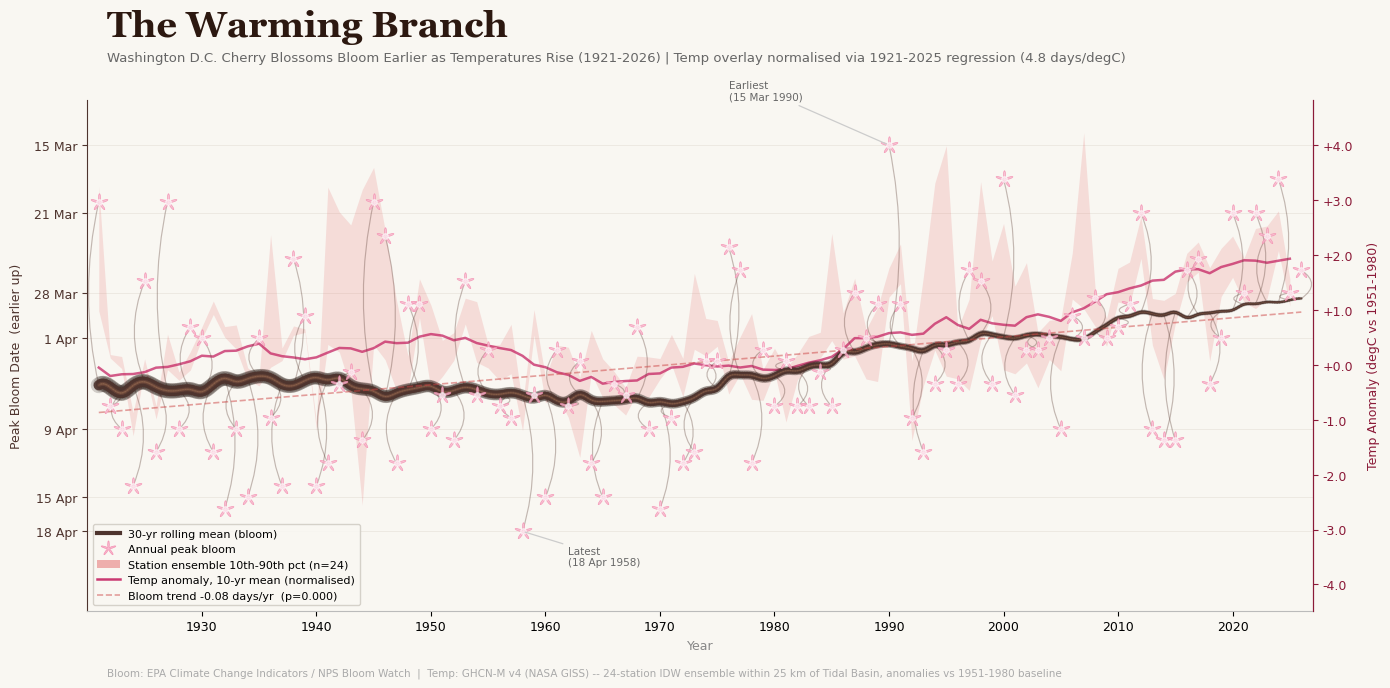

In [5]:
# --- Cell 4: "The Warming Branch" figure ---
# Design spec: Gemini editorial plan (NYT aesthetic), 2026-04-12
#
# Z-order layering:
#   1 : grid / background
#   2 : ensemble bounds (reddish-pink dashed)  -- behind everything
#   2 : temperature line (reddish-pink solid)  -- behind branch
#   3 : Bezier twigs (brown, alpha 0.35)
#   4 : branch (tapered LineCollection, deep umber)
#   5 : trend line (dashed red)
#   6 : sakura blossom markers
#   7 : white centre dots on blossoms
#
# Axes:
#   LHS (primary, inverted) : peak bloom date in calendar units
#   RHS (twinx)             : temperature anomaly in degC, locked to LHS via normalization
#
# Temp normalization:
#   DOY_vis = temp_norm_offset - anomaly * temp_norm_scale
#   Computed from OLS regression DOY ~ Anomaly over overlap years (see Cell 3 output).

import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from matplotlib.path import Path as MPath
from datetime import date as _dt, timedelta as _td
from scipy.interpolate import make_interp_spline
from collections import defaultdict as _dd

# ---- Calendar-date helpers -------------------------------------------------
def doy_to_label(doy, ref_year=2001):
    d = _dt(ref_year, 1, 1) + _td(days=int(doy) - 1)
    return d.strftime("%-d %b")

def doy_to_actual_label(doy, year):
    d = _dt(int(year), 1, 1) + _td(days=int(doy) - 1)
    return d.strftime("%-d %b")

# ---- Temp -> DOY normalisation (and inverse) --------------------------------
def temp_to_doy(a):
    return temp_norm_offset - np.asarray(a) * temp_norm_scale

def doy_to_temp(d):
    return (temp_norm_offset - np.asarray(d)) / temp_norm_scale

# ---- Sakura 5-petal Path marker --------------------------------------------
def make_sakura_marker(n_petals=5):
    verts, codes = [], []
    angles = np.linspace(np.pi / 2, np.pi / 2 + 2 * np.pi, n_petals, endpoint=False)
    r_inner, r_tip, r_ctrl = 0.20, 1.00, 0.92
    half_w = (np.pi / n_petals) * 0.65
    for i, a in enumerate(angles):
        base_l = (r_inner * np.cos(a - half_w), r_inner * np.sin(a - half_w))
        base_r = (r_inner * np.cos(a + half_w), r_inner * np.sin(a + half_w))
        ctrl_l = (r_ctrl  * np.cos(a - half_w * 0.45), r_ctrl * np.sin(a - half_w * 0.45))
        ctrl_r = (r_ctrl  * np.cos(a + half_w * 0.45), r_ctrl * np.sin(a + half_w * 0.45))
        tip    = (r_tip   * np.cos(a), r_tip * np.sin(a))
        verts += [base_l]
        codes += [MPath.MOVETO if i == 0 else MPath.LINETO]
        verts += [ctrl_l, tip, ctrl_r, base_r]
        codes += [MPath.CURVE3, MPath.CURVE3, MPath.CURVE3, MPath.CURVE3]
    verts += [verts[0]]
    codes += [MPath.CLOSEPOLY]
    return MPath(verts, codes)

SAKURA = make_sakura_marker()

# ---- Tapered branch --------------------------------------------------------
def draw_branch(ax, xdata, ydata, lw_max=7.5, lw_min=1.5):
    pts  = np.array([xdata, ydata]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lws  = np.linspace(lw_max, lw_min, len(segs))
    layers = [
        ("#1a0a04", 1.55, 0.18),
        ("#4E342E", 1.00, 0.90),
        ("#7a5040", 0.40, 0.32),
        ("#c4936a", 0.16, 0.20),
    ]
    for color, lw_mult, alpha in layers:
        lc = LineCollection(segs, linewidths=lws * lw_mult,
                            colors=color, alpha=alpha, zorder=4,
                            capstyle="round", joinstyle="round")
        ax.add_collection(lc)

# ---- Bezier twig -----------------------------------------------------------
def draw_twig(ax, year, branch_doy, bloom_doy):
    bow   = 1.8 * (1 if int(year) % 2 == 0 else -1)
    start = (year, branch_doy)
    ctrl  = (year + bow, (branch_doy + bloom_doy) / 2.0)
    end   = (year, bloom_doy)
    path  = MPath([start, ctrl, end],
                  [MPath.MOVETO, MPath.CURVE3, MPath.CURVE3])
    patch = mpatches.PathPatch(path, facecolor="none",
                               edgecolor="#5D4037", lw=0.85, alpha=0.35, zorder=3)
    ax.add_patch(patch)

# ---- Palette ---------------------------------------------------------------
BG_COLOR     = "#F9F7F2"
BRANCH_COLOR = "#4E342E"
TEMP_COLOR   = "#c2185b"   # reddish-pink temperature line
BOUND_COLOR  = "#e57373"   # lighter reddish-pink for bounds
BLOOM_FILL   = "#F8BBD0"
BLOOM_EDGE   = "#F48FB1"
TREND_COLOR  = "#c44"
ANNO_COLOR   = "#666666"
TEMP_AXIS_C  = "#8b1a38"   # RHS axis label/tick colour

plt.rcParams.update({
    "font.family":    "DejaVu Sans",
    "axes.grid":      True,
    "axes.grid.axis": "y",
    "grid.color":     "#e8e4dc",
    "grid.linewidth": 0.5,
})

# ---- Figure setup ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 7))
ax_t = ax.twinx()         # RHS axis: temperature anomaly in degC

fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)
ax_t.set_facecolor("none")
ax.set_axisbelow(True)
ax_t.set_axisbelow(False)
ax_t.grid(False)

# Spines
for sp in ["top", "left"]:
    ax.spines[sp].set_visible(False)
    ax_t.spines[sp].set_visible(False)
ax.spines["bottom"].set_color("#bbbbbb")
ax.spines["right"].set_color(TEMP_AXIS_C)
ax_t.spines["right"].set_color(TEMP_AXIS_C)
ax_t.spines["bottom"].set_visible(False)

# ---- Year range ------------------------------------------------------------
all_years = sorted(df_sorted["Year"].unique())
yr_min, yr_max = min(all_years), max(all_years)
yr_arr = df_sorted["Year"].values

# ---- DOY view limits (explicit, for twin-axis calibration) -----------------
DOY_VIEW_EARLY = 70    # top of inverted axis  (earliest possible bloom)
DOY_VIEW_LATE  = 115   # bottom of inverted axis (latest possible bloom)

# ---- Ensemble bounds: per-year min/max across all stations -----------------
# Normalised to DOY visual space; plotted on primary axis at low zorder
_yv = _dd(list)
for _sid, _adict in station_anoms.items():
    for _yr, _val in _adict.items():
        _yv[_yr].append(_val)
_b_years = sorted(_yv.keys())
_b_max   = np.array([max(_yv[y]) for y in _b_years])
_b_min   = np.array([min(_yv[y]) for y in _b_years])

# Winsorized shaded band: 10th–90th percentile across stations at each year
# (clips extreme single-station outliers; preserves ensemble spread signal)
_b_p10 = np.array([np.percentile(_yv[y], 10) for y in _b_years])
_b_p90 = np.array([np.percentile(_yv[y], 90) for y in _b_years])
ax.fill_between(_b_years,
                temp_to_doy(_b_p90),   # cooler bound -> later DOY -> visual bottom
                temp_to_doy(_b_p10),   # warmer bound -> earlier DOY -> visual top
                color=BOUND_COLOR, alpha=0.20, zorder=2, linewidth=0)

# ---- Temperature line: IDW ensemble 30-yr rolling mean (normalised) --------
_ts = df_temp.sort_values("Year").copy()
_ts["Temp_Rolling"] = _ts["Anomaly"].rolling(10, center=True, min_periods=5).mean()
_tr = _ts.dropna(subset=["Temp_Rolling"])
ax.plot(_tr["Year"].values, temp_to_doy(_tr["Temp_Rolling"].values),
        color=TEMP_COLOR, linewidth=1.8, alpha=0.70, zorder=2,
        label="Temp anomaly, 10-yr mean")

# ---- Branch: spline-smoothed 30-yr rolling mean ----------------------------
_roll = df_sorted.dropna(subset=["DOY_roll30"]).sort_values("Year")
_rx   = _roll["Year"].values.astype(float)
_ry   = _roll["DOY_roll30"].values
_xf   = np.linspace(_rx[0], _rx[-1], 500)
_yf   = make_interp_spline(_rx, _ry, k=3)(_xf)
draw_branch(ax, _xf, _yf)

# ---- Trend dashed line + shading -------------------------------------------
trend_y = slope * df_sorted["Year"] + intercept
ax.plot(yr_arr, trend_y, color=TREND_COLOR, linestyle="--",
        linewidth=1.2, alpha=0.50, zorder=5,
        label=f"Bloom trend {slope:+.2f} days/yr  (p={p_val:.3f})")

# ---- Bezier twigs ----------------------------------------------------------
for _, row in df_sorted.iterrows():
    if np.isnan(row["DOY_roll30"]):
        continue
    if abs(row["DOY"] - row["DOY_roll30"]) < 0.4:
        continue
    draw_twig(ax, float(row["Year"]), float(row["DOY_roll30"]), float(row["DOY"]))

# ---- Sakura blossom markers ------------------------------------------------
ax.scatter(yr_arr, df_sorted["DOY"].values,
           marker=SAKURA, s=160,
           facecolor=BLOOM_FILL, edgecolor=BLOOM_EDGE,
           linewidths=0.55, alpha=0.82, zorder=6)
ax.scatter(yr_arr, df_sorted["DOY"].values,
           marker="o", s=16, color="white", alpha=0.55, zorder=7)

# ---- Primary axis (bloom DOY, inverted, calendar labels) -------------------
ax.invert_yaxis()
ax.set_ylim(DOY_VIEW_LATE, DOY_VIEW_EARLY)   # matplotlib: bottom=115, top=70

doy_ticks = [74, 80, 87, 91, 99, 105, 108]
ax.set_yticks(doy_ticks)
ax.set_yticklabels([doy_to_label(d) for d in doy_ticks],
                   fontsize=9, color=BRANCH_COLOR)
ax.set_ylabel("Peak Bloom Date  (earlier up)", fontsize=9,
              color=BRANCH_COLOR, labelpad=8)
ax.tick_params(axis="y", colors=BRANCH_COLOR)
ax.spines["left"].set_color(BRANCH_COLOR)
ax.spines["left"].set_visible(True)

# ---- Secondary axis (temperature anomaly, degC) ----------------------------
# Calibrated to primary via normalization formula so temp_to_doy() is consistent.
anom_at_top    = doy_to_temp(DOY_VIEW_EARLY)   # warmest end (visual top)
anom_at_bottom = doy_to_temp(DOY_VIEW_LATE)    # coolest end (visual bottom)
ax_t.set_ylim(anom_at_bottom, anom_at_top)

# Tick marks at clean degC intervals
import math
_anom_range = anom_at_top - anom_at_bottom
_step = 0.5 if _anom_range < 4 else 1.0
_t0   = math.ceil(anom_at_bottom / _step) * _step
_t1   = math.floor(anom_at_top   / _step) * _step
_temp_ticks = np.arange(_t0, _t1 + _step * 0.5, _step)
ax_t.set_yticks(_temp_ticks)
ax_t.set_yticklabels([f"{v:+.1f}" for v in _temp_ticks],
                     fontsize=9, color=TEMP_AXIS_C)
ax_t.set_ylabel("Temp Anomaly (degC vs 1951-1980)", fontsize=9,
                color=TEMP_AXIS_C, labelpad=10)
ax_t.tick_params(axis="y", colors=TEMP_AXIS_C)

# ---- X-axis ----------------------------------------------------------------
ax.set_xlim(yr_min - 1, yr_max + 1)
ax.set_xticks(list(range(1930, 2030, 10)))
ax.set_xticklabels(list(range(1930, 2030, 10)), fontsize=9)
ax.set_xlabel("Year", fontsize=9, color="#888888")

# ---- Annotations: earliest and latest bloom --------------------------------
earliest = df_sorted.loc[df_sorted["DOY"].idxmin()]
latest   = df_sorted.loc[df_sorted["DOY"].idxmax()]

ax.annotate(
    f"Earliest\n({doy_to_actual_label(earliest.DOY, earliest.Year)} {int(earliest.Year)})",
    xy=(earliest.Year, earliest.DOY),
    xytext=(earliest.Year - 14, earliest.DOY - 4),
    fontsize=7.5, color=ANNO_COLOR,
    arrowprops=dict(arrowstyle="-", color="#cccccc", lw=0.9), zorder=8)
ax.annotate(
    f"Latest\n({doy_to_actual_label(latest.DOY, latest.Year)} {int(latest.Year)})",
    xy=(latest.Year, latest.DOY),
    xytext=(latest.Year + 4, latest.DOY + 3),
    fontsize=7.5, color=ANNO_COLOR,
    arrowprops=dict(arrowstyle="-", color="#cccccc", lw=0.9), zorder=8)

# ---- Legend ----------------------------------------------------------------
branch_proxy = mlines.Line2D([], [], color=BRANCH_COLOR, linewidth=3.0,
                              label="30-yr rolling mean (bloom)")
blossom_proxy = mlines.Line2D([], [], marker=SAKURA, markersize=11, linestyle="none",
                               markerfacecolor=BLOOM_FILL, markeredgecolor=BLOOM_EDGE,
                               markeredgewidth=0.5, label="Annual peak bloom")
bound_proxy  = mpatches.Patch(facecolor=BOUND_COLOR, alpha=0.55, edgecolor="none",
                              label=f"Station ensemble 10th-90th pct (n={len(station_anoms)})")
temp_proxy   = mlines.Line2D([], [], color=TEMP_COLOR, linewidth=1.8, alpha=0.85,
                              label="Temp anomaly, 10-yr mean (normalised)")
h_ax, l_ax = ax.get_legend_handles_labels()
# h_ax/l_ax picks up the trend line; filter out temp line (already in proxy)
trend_pairs = [(h, l) for h, l in zip(h_ax, l_ax)
               if "Temp" not in l and "nolegend" not in l]

ax.legend(
    [branch_proxy, blossom_proxy, bound_proxy, temp_proxy]
    + [h for h, _ in trend_pairs],
    [branch_proxy.get_label(), blossom_proxy.get_label(),
     bound_proxy.get_label(),  temp_proxy.get_label()]
    + [l for _, l in trend_pairs],
    loc="lower left", fontsize=8.0, framealpha=0.88,
    edgecolor="#d0ccc4", facecolor=BG_COLOR)

# ---- Title, subtitle, source note ------------------------------------------
try:
    fig.text(0.08, 0.97, "The Warming Branch",
             ha="left", va="top",
             fontfamily="Georgia", fontsize=26, fontweight="bold", color="#2C1810")
except Exception:
    fig.text(0.08, 0.97, "The Warming Branch",
             ha="left", va="top", fontsize=26, fontweight="bold", color="#2C1810")

fig.text(
    0.08, 0.91,
    f"Washington D.C. Cherry Blossoms Bloom Earlier as Temperatures Rise (1921-2026) | "
    f"Temp overlay normalised via {reg_yr_min}-{reg_yr_max} regression "
    f"({temp_norm_scale:.1f} days/degC)",
    ha="left", va="top", fontsize=9.5, color="#666666")

fig.text(
    0.08, 0.018,
    "Bloom: EPA Climate Change Indicators / NPS Bloom Watch  |  "
    f"Temp: GHCN-M v4 (NASA GISS) -- {len(station_anoms)}-station IDW ensemble "
    "within 25 km of Tidal Basin, anomalies vs 1951-1980 baseline",
    ha="left", fontsize=7.5, color="#aaaaaa")

plt.tight_layout(rect=[0, 0.03, 1, 0.89])

OUT_PATH = f"output/dc_bloom_vs_temp_{yr_min}_{yr_max}.png"
plt.savefig(OUT_PATH, dpi=180, bbox_inches="tight", facecolor=BG_COLOR)
print(f"Figure saved to {OUT_PATH}")
plt.show()


## Station Map: GHCN-M v4 Temperature Ensemble

The temperature overlay in the main figure is derived from an inverse-distance-weighted (IDW) ensemble of **24 GHCN-M v4 QCF stations** within 25 km of the Tidal Basin reference site (38.889°N, 77.037°W). The map below validates the station selection and spatial coverage.

**Data source:** NOAA/NCEI GHCN Monthly v4 QCF (`ghcnm.tavg.latest.qcf.tar.gz`), downloaded 2026-04-12.  
**Inventory URL:** https://www.ncei.noaa.gov/pub/data/ghcn/v4/

**Ensemble construction:**
- Per-station annual mean TAVG computed from monthly values with ≥8 valid months
- Anomalies computed relative to each station's 1951–1980 baseline (minimum 15 years required)
- IDW weights: $w_i = 1 / d_i^2$ where $d_i$ is distance in km from the Tidal Basin
- Ensemble mean at each year weighted across all stations with valid anomalies that year

**Key stations:** WASHINGTON (USW00093725, 2.3 km) provides the densest local record but ends in 2014; WASHINGTON REAGAN AP (USW00013743, 4.5 km) extends through 2025. The ensemble approach handles these record gaps naturally — each station contributes only for years it has valid data.


Saved output/station_map.png


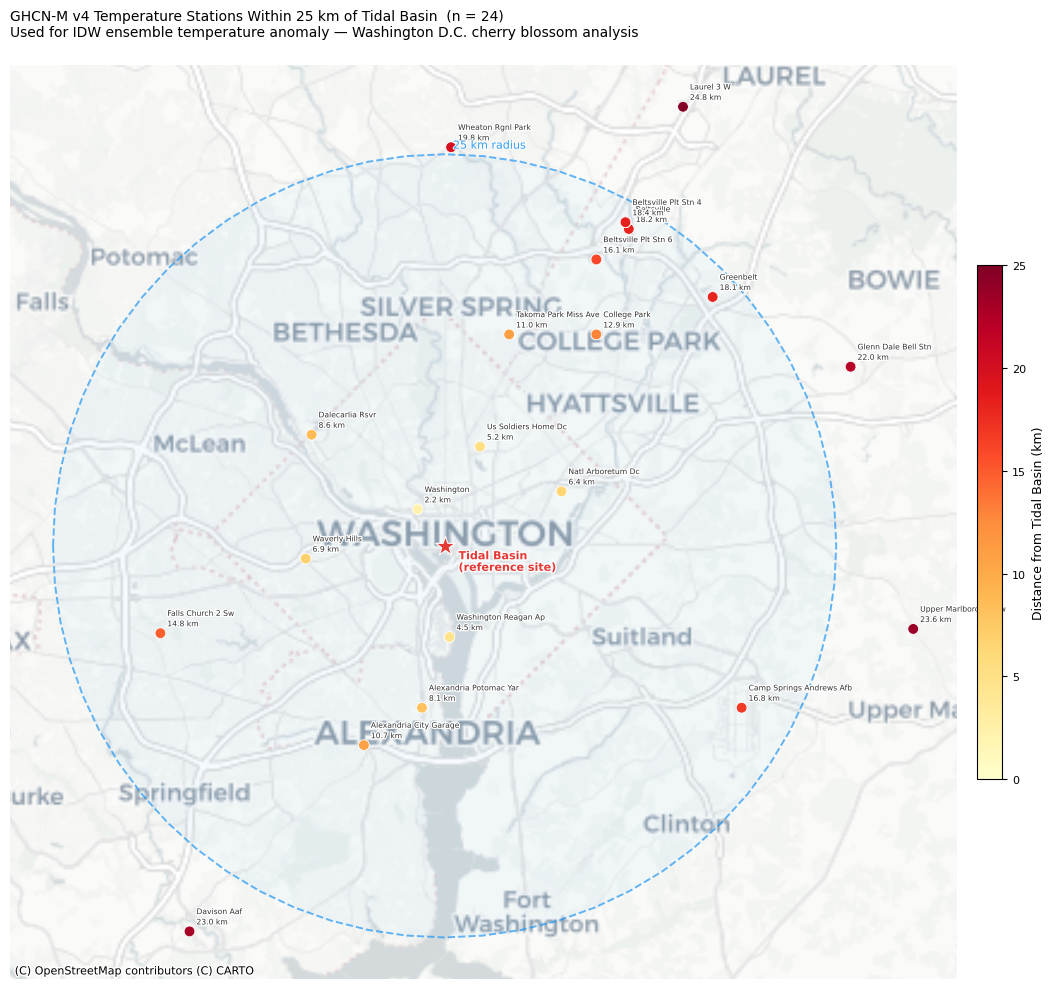

In [6]:
# --- Station Map: validation figure ---
# Plots all 24 GHCN-M v4 stations within 25 km of the Tidal Basin.
# Requires: geopandas, contextily (both available in this environment).
# Output: output/station_map.png

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import contextily as ctx
from shapely.geometry import Point

TIDAL_BASIN = (38.8890, -77.0370)
RADIUS_KM   = 25.0

df_stn = pd.read_csv("data/ghcnm_station_meta.csv", comment="#")
df_stn.columns = df_stn.columns.str.strip()

gdf = gpd.GeoDataFrame(
    df_stn,
    geometry=gpd.points_from_xy(df_stn["Lon"], df_stn["Lat"]),
    crs="EPSG:4326",
)
ref = gpd.GeoDataFrame(
    [{"Name": "Tidal Basin (ref)", "Dist_km": 0.0,
      "geometry": Point(TIDAL_BASIN[1], TIDAL_BASIN[0])}],
    crs="EPSG:4326",
)
gdf_m  = gdf.to_crs("EPSG:3857")
ref_m  = ref.to_crs("EPSG:3857")
ref_pt = ref_m.geometry.iloc[0]
circle = gpd.GeoDataFrame(geometry=[ref_pt.buffer(RADIUS_KM * 1000)], crs="EPSG:3857")

cmap   = plt.cm.YlOrRd
norm   = plt.Normalize(vmin=0, vmax=RADIUS_KM)
colors = cmap(norm(gdf_m["Dist_km"]))

fig, ax = plt.subplots(figsize=(11, 10))

circle.boundary.plot(ax=ax, color="#2196F3", linewidth=1.4,
                     linestyle="--", alpha=0.7, zorder=3)
circle.plot(ax=ax, color="#2196F3", alpha=0.04, zorder=2)

gdf_m.plot(ax=ax, color=colors, markersize=60, zorder=5,
           edgecolor="white", linewidth=0.6)
ref_m.plot(ax=ax, marker="*", color="#e53935", markersize=220,
           zorder=6, edgecolor="white", linewidth=0.8)

for _, row in gdf_m.iterrows():
    x, y = row.geometry.x, row.geometry.y
    label = f"{row['Name'].replace('_', ' ').title()}\n{row['Dist_km']:.1f} km"
    ax.annotate(label, xy=(x, y), xytext=(5, 5), textcoords="offset points",
                fontsize=5.5, color="#333333",
                path_effects=[pe.withStroke(linewidth=1.8, foreground="white")],
                zorder=7)

rx, ry = ref_pt.x, ref_pt.y
ax.annotate("Tidal Basin\n(reference site)", xy=(rx, ry), xytext=(10, -18),
            textcoords="offset points", fontsize=8, fontweight="bold", color="#e53935",
            path_effects=[pe.withStroke(linewidth=2, foreground="white")], zorder=8)

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=10)
except Exception:
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=10)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cb.set_label("Distance from Tidal Basin (km)", fontsize=9)
cb.ax.tick_params(labelsize=8)

ax.annotate("25 km radius",
            xy=(rx, ry + RADIUS_KM * 1000), xytext=(6, 4),
            textcoords="offset points", fontsize=8, color="#2196F3", alpha=0.9,
            path_effects=[pe.withStroke(linewidth=1.5, foreground="white")], zorder=7)

ax.set_axis_off()
ax.set_title(
    f"GHCN-M v4 Temperature Stations Within {RADIUS_KM:.0f} km of Tidal Basin  "
    f"(n = {len(df_stn)})\n"
    "Used for IDW ensemble temperature anomaly — Washington D.C. cherry blossom analysis",
    fontsize=10, loc="left", pad=10,
)
plt.tight_layout()
OUT = "output/station_map.png"
plt.savefig(OUT, dpi=180, bbox_inches="tight", facecolor="white")
print(f"Saved {OUT}")
plt.show()
